In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score
from sklearn.metrics import ConfusionMatrixDisplay
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from model_pipelines.first_level_feature_selectors import *
from model_pipelines.auxilliary_functions import find_common_elements
from eda.scoring_function import score_model_optimal_k
from model_pipelines.first_level_feature_selectors import random_forest_selector
from model_pipelines.xgb_classifier import train_model_growing_subset

In [2]:
x_train=pd.read_csv("C:\\Users\\andrz\\Downloads\\data\\data\\x_train.txt",sep=" ")
x_test=pd.read_csv("C:\\Users\\andrz\\Downloads\\data\\data\\x_test.txt",sep=" ")
y_train=pd.read_csv("C:\\Users\\andrz\\Downloads\\data\\data\\y_train.txt")

In [3]:
best_mi_features=select_best_mutual_information(x_train,y_train,20)
print(best_mi_features)
best_corr_features=select_best_correlation(x_train,y_train,20)
print(best_corr_features)
best_ks_features, ranking_df=Kolmogorov_Smirnov_selector(x_train,y_train.squeeze(),20)
print(best_ks_features)
best_rf_features=random_forest_selector(x_train,y_train,20)
print(best_rf_features)
# best_rf_features_uncorr=random_forest_selector(x_train,y_train,20,vif_check=True)
# print(best_rf_features_uncorr)
best_xgb_features_df=xgb_selector(x_train,y_train,20)
print(best_xgb_features_df)
# best_xgb_features_uncorr_df=xgb_selector(x_train,y_train,20,vif_check=True)
# print(best_xgb_features_uncorr_df)

['V54', 'V107', 'V29', 'V207', 'V123', 'V4', 'V378', 'V357', 'V112', 'V151', 'V49', 'V437', 'V240', 'V354', 'V37', 'V167', 'V285', 'V389', 'V225', 'V202']
['V390', 'V224', 'V161', 'V175', 'V32', 'V11', 'V199', 'V345', 'V329', 'V309', 'V176', 'V265', 'V255', 'V191', 'V60', 'V313', 'V443', 'V120', 'V46', 'V5']
['V224', 'V255', 'V11', 'V265', 'V176', 'V161', 'V191', 'V329', 'V309', 'V175', 'V32', 'V46', 'V345', 'V199', 'V60', 'V390', 'V160', 'V416', 'V313', 'V483']


C:\Users\andrz\-Cost-Sensitive-Predictive-Modeling\.venv\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


['V191', 'V255', 'V176', 'V160', 'V380', 'V416', 'V215', 'V342', 'V483', 'V199', 'V117', 'V262', 'V46', 'V390', 'V224', 'V265', 'V227', 'V175', 'V161', 'V329']
    Feature  Gain (Importance)
10      V11          17.134403
262    V265           9.262294
173    V176           8.722813
172    V174           8.714650
158    V160           8.644564
188    V191           8.354898
45      V46           7.966691
252    V255           7.704970
134    V136           7.632964
421    V425           7.563189
212    V215           7.272226
154    V156           6.835529
377    V380           6.713578
339    V342           6.662626
116    V117           6.637785
108    V109           6.562385
326    V329           6.349121
224    V227           6.258576
305    V308           6.256776
259    V262           6.077317


In [15]:
all_features_rf_sorted=random_forest_selector(x_train,y_train,500)

C:\Users\andrz\-Cost-Sensitive-Predictive-Modeling\.venv\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [4]:
best_xgb_features=best_xgb_features_df['Feature'].to_list()

In [13]:
xgb_rf_common=find_common_elements(best_rf_features,best_xgb_features)
print(xgb_rf_common)
print(len(xgb_rf_common))

['V380', 'V265', 'V160', 'V117', 'V329', 'V176', 'V215', 'V227', 'V262', 'V255', 'V342', 'V191', 'V46']
13


In [6]:
x_train_t,x_train_v,y_train_t,y_train_v=train_test_split(x_train,y_train,test_size=0.5,random_state=10)

Best threshold: 0.53543425
Best threshold: 0.56903964
Best threshold: 0.57755643
Best threshold: 0.59141636
Best threshold: 0.5919771
Best threshold: 0.5869796
Best threshold: 0.6097058
Best threshold: 0.5918751
Best threshold: 0.5950302
Best threshold: 0.5917724
Best threshold: 0.57169825
Best threshold: 0.5959295
Best threshold: 0.58400965
Best threshold: 0.586878
Best threshold: 0.5991302
Best threshold: 0.5953531
Best threshold: 0.5935725
Best threshold: 0.58948183
Best threshold: 0.59192115
Best threshold: 0.59187067


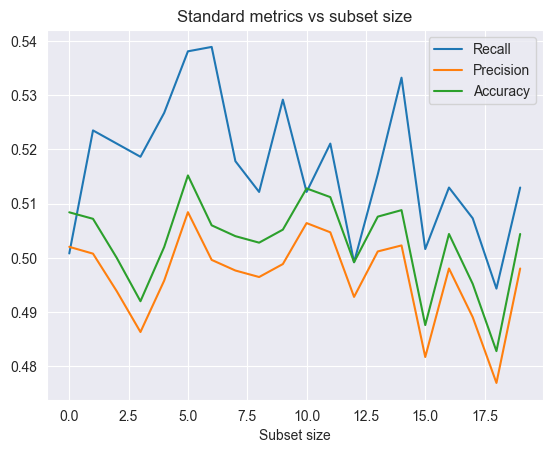

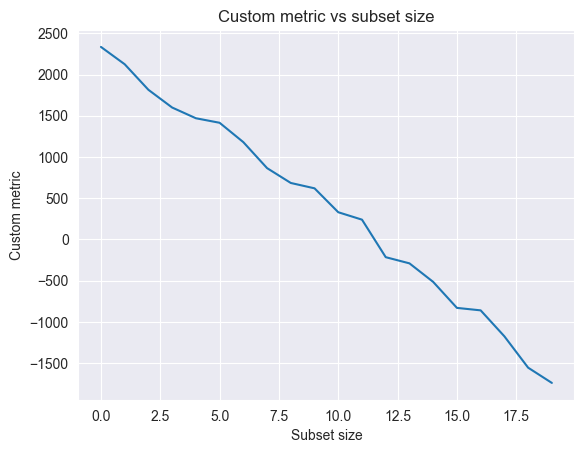

In [7]:
mi_xgb,mi_xgb_ft=train_model_growing_subset(x_train_t,y_train_t,x_train_v,y_train_v,best_mi_features)

Best threshold: 0.52545017
Best threshold: 0.5395519
Best threshold: 0.5476545
Best threshold: 0.5594239
Best threshold: 0.5594239
Best threshold: 0.5741989
Best threshold: 0.579115
Best threshold: 0.5883861
Best threshold: 0.57010615
Best threshold: 0.58284265
Best threshold: 0.57817984
Best threshold: 0.5675824
Best threshold: 0.57225627
Best threshold: 0.5844303
Best threshold: 0.5953674
Best threshold: 0.5863187
Best threshold: 0.58351386
Best threshold: 0.5789762
Best threshold: 0.59713227
Best threshold: 0.58684576


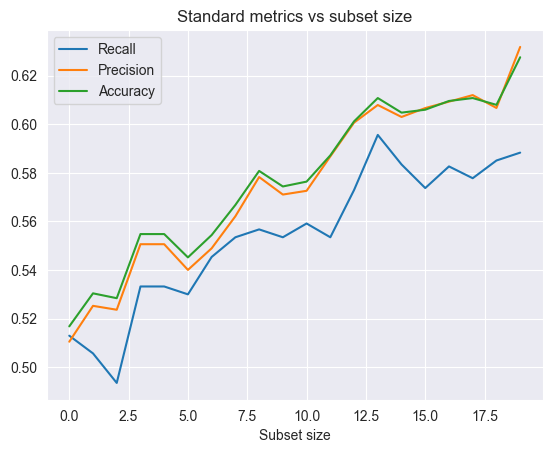

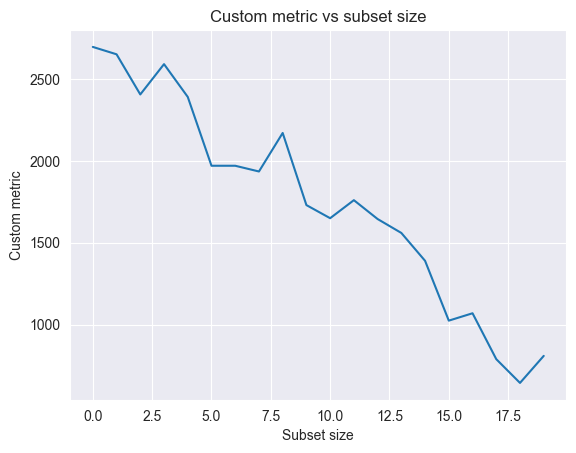

In [8]:
corr_xgb,corr_xgb_ft=train_model_growing_subset(x_train_t,y_train_t,x_train_v,y_train_v,best_corr_features)

Best threshold: 0.54015857
Best threshold: 0.54806674
Best threshold: 0.55453974
Best threshold: 0.56808364
Best threshold: 0.56224716
Best threshold: 0.56203103
Best threshold: 0.5620703
Best threshold: 0.5604394
Best threshold: 0.56224364
Best threshold: 0.58304536
Best threshold: 0.58304536
Best threshold: 0.5774087
Best threshold: 0.5734741
Best threshold: 0.5731159
Best threshold: 0.5879536
Best threshold: 0.58208615
Best threshold: 0.58347774
Best threshold: 0.58347774
Best threshold: 0.58787066
Best threshold: 0.59135747


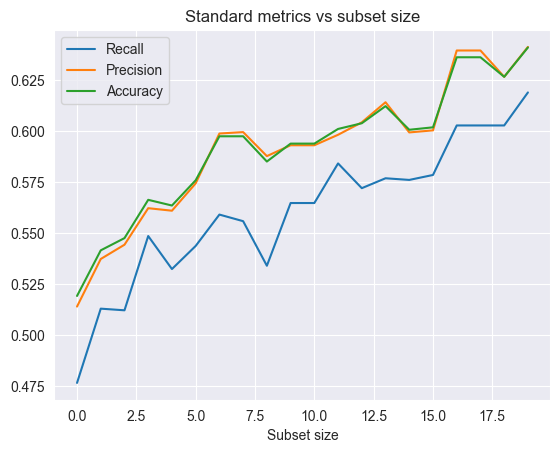

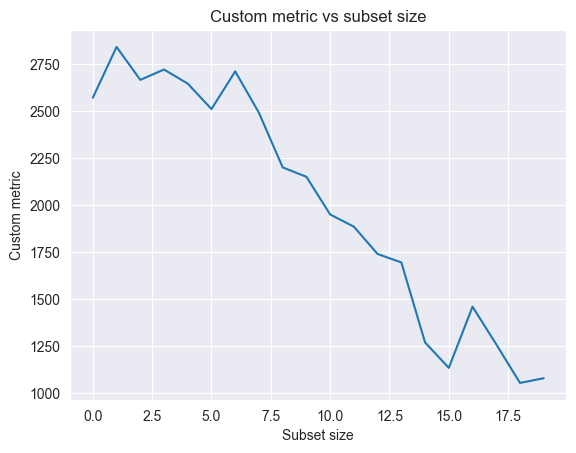

In [9]:
ks_xgb,ks_xgb_ft=train_model_growing_subset(x_train_t,y_train_t,x_train_v,y_train_v,best_ks_features)

Best threshold: 0.55093324
Best threshold: 0.5411667
Best threshold: 0.5406106
Best threshold: 0.56837064
Best threshold: 0.56562907
Best threshold: 0.56562907
Best threshold: 0.56765217
Best threshold: 0.5832866
Best threshold: 0.57435423
Best threshold: 0.58418834
Best threshold: 0.5768414
Best threshold: 0.57728785
Best threshold: 0.5862709
Best threshold: 0.6121647
Best threshold: 0.60731435
Best threshold: 0.579928
Best threshold: 0.5946526
Best threshold: 0.59448487
Best threshold: 0.58110577
Best threshold: 0.6010442


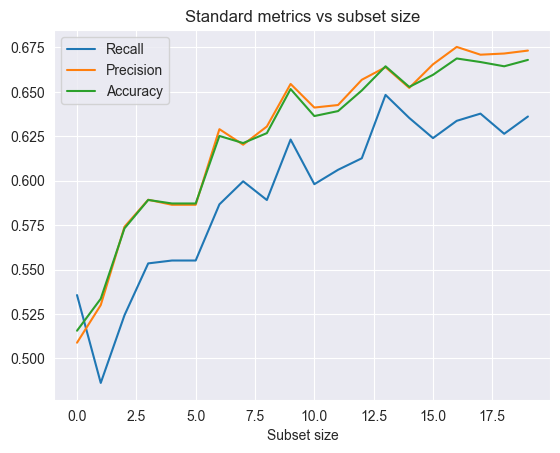

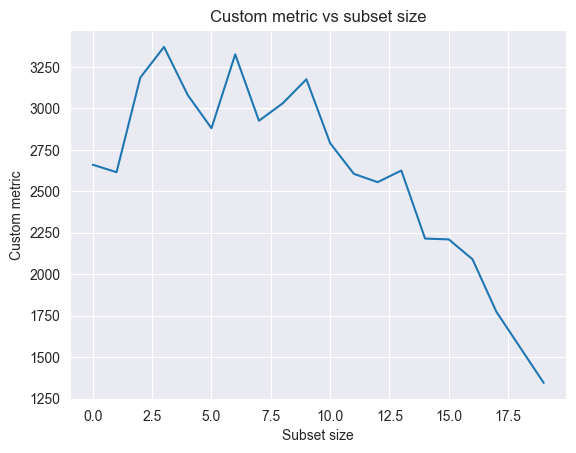

In [10]:
rf_xgb,rf_xgb_ft=train_model_growing_subset(x_train_t,y_train_t,x_train_v,y_train_v,best_rf_features)

Best threshold: 0.53148097
Best threshold: 0.558729
Best threshold: 0.55937666
Best threshold: 0.56988263
Best threshold: 0.5725751
Best threshold: 0.57125396
Best threshold: 0.5752648
Best threshold: 0.58036166
Best threshold: 0.5757216
Best threshold: 0.57961357
Best threshold: 0.57125854
Best threshold: 0.5678098
Best threshold: 0.59475464
Best threshold: 0.5818846
Best threshold: 0.58306384
Best threshold: 0.56461865
Best threshold: 0.5735304
Best threshold: 0.581867
Best threshold: 0.61159986
Best threshold: 0.59041846


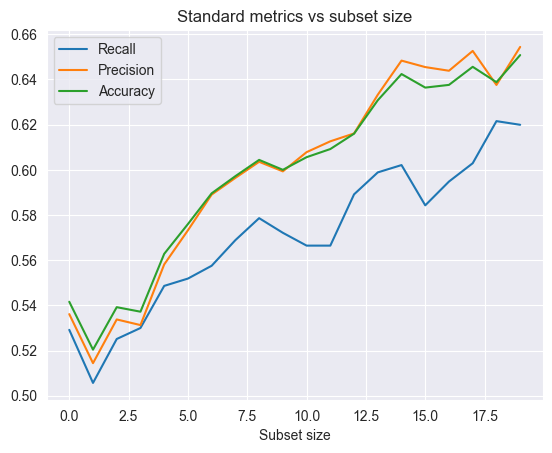

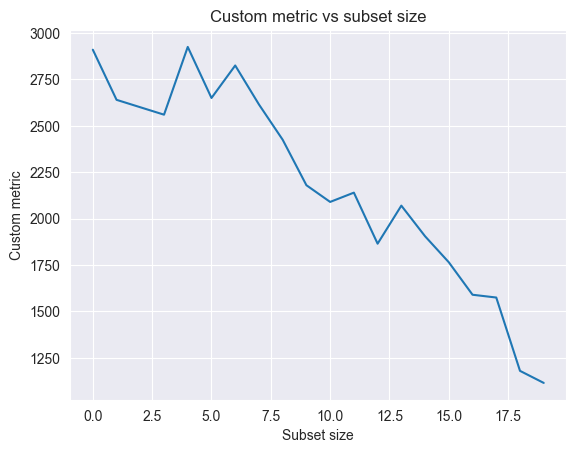

In [11]:
xgb_xgb,xgb_xgb_ft=train_model_growing_subset(x_train_t,y_train_t,x_train_v,y_train_v,best_xgb_features)

Best threshold: 0.55093324
Best threshold: 0.5411667
Best threshold: 0.5406106
Best threshold: 0.56837064
Best threshold: 0.56562907
Best threshold: 0.56562907
Best threshold: 0.56765217
Best threshold: 0.5832866
Best threshold: 0.57435423
Best threshold: 0.58418834
Best threshold: 0.5768414
Best threshold: 0.57728785
Best threshold: 0.5862709
Best threshold: 0.6121647
Best threshold: 0.60731435
Best threshold: 0.579928
Best threshold: 0.5946526
Best threshold: 0.59448487
Best threshold: 0.58110577
Best threshold: 0.6010442
Best threshold: 0.5818803
Best threshold: 0.5818803
Best threshold: 0.58119047
Best threshold: 0.58219874
Best threshold: 0.5817906
Best threshold: 0.5976189
Best threshold: 0.59516704
Best threshold: 0.59258014
Best threshold: 0.59531224
Best threshold: 0.5996726
Best threshold: 0.58031267
Best threshold: 0.5880036
Best threshold: 0.59806925
Best threshold: 0.58805233
Best threshold: 0.5833365
Best threshold: 0.60889745
Best threshold: 0.5864767
Best threshold: 0.5

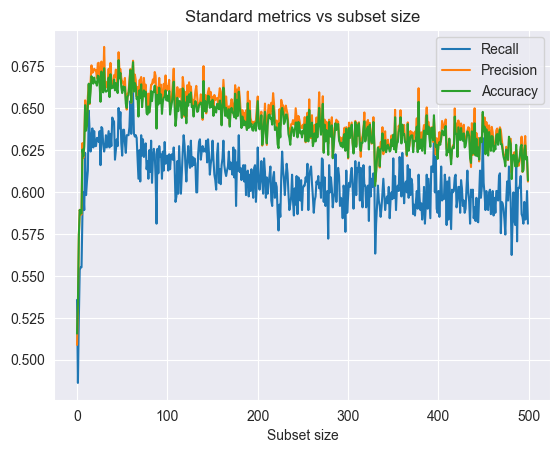

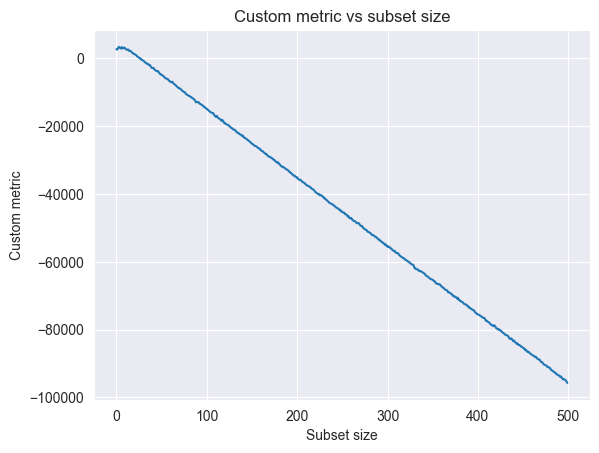

In [16]:
all_xgb,all_xgb_ft=train_model_growing_subset(x_train_t,y_train_t,x_train_v,y_train_v,all_features_rf_sorted)